# Reward per episode

plot the cumulative reward per episode against terminated episodes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('run/2026-4-21_19-0-12/consolidated_episodes.xlsx')
df.head()

,episode,steps,cum_progress,cum_energy_efficiency,cum_smoothness,cum_total_reward,status,env_id,env_steps,global_steps,ended_terminated,ended_truncated
0,1,157,39.561864,13.144979,6.521923,59.228765,terminated,0,157,157,True,False
1,2,173,38.338311,23.790225,29.511719,91.640255,terminated,0,330,330,True,False
2,3,181,37.854438,19.871328,18.983480,76.709245,terminated,0,511,511,True,False
3,4,171,38.713706,19.092448,29.919148,87.725302,terminated,0,682,682,True,False
4,5,159,39.675172,19.196036,33.157615,92.028822,terminated,0,841,841,True,False


In [14]:
df['progress_norm'] = df['cum_progress']/df['steps']
df['progress_mean'] = df['progress_norm'].rolling(window=5, center=True).mean()
df['progress_std'] = df['progress_norm'].rolling(window=5, center=True).std()
df['energy_efficiency_norm'] = df['cum_energy_efficiency']/df['steps']
df['energy_efficiency_mean'] = df['energy_efficiency_norm'].rolling(window=5, center=True).mean()
df['energy_efficiency_std'] = df['energy_efficiency_norm'].rolling(window=5, center=True).std()
df['smoothness_norm'] = df['cum_smoothness']/df['steps']
df['smoothness_mean'] = df['smoothness_norm'].rolling(window=5, center=True).mean()
df['smoothness_std'] = df['smoothness_norm'].rolling(window=5, center=True).std()
df['episode_length_mean'] = df['steps'].rolling(window=5, center=True).mean()
df['episode_length_std'] = df['steps'].rolling(window=5, center=True).std()


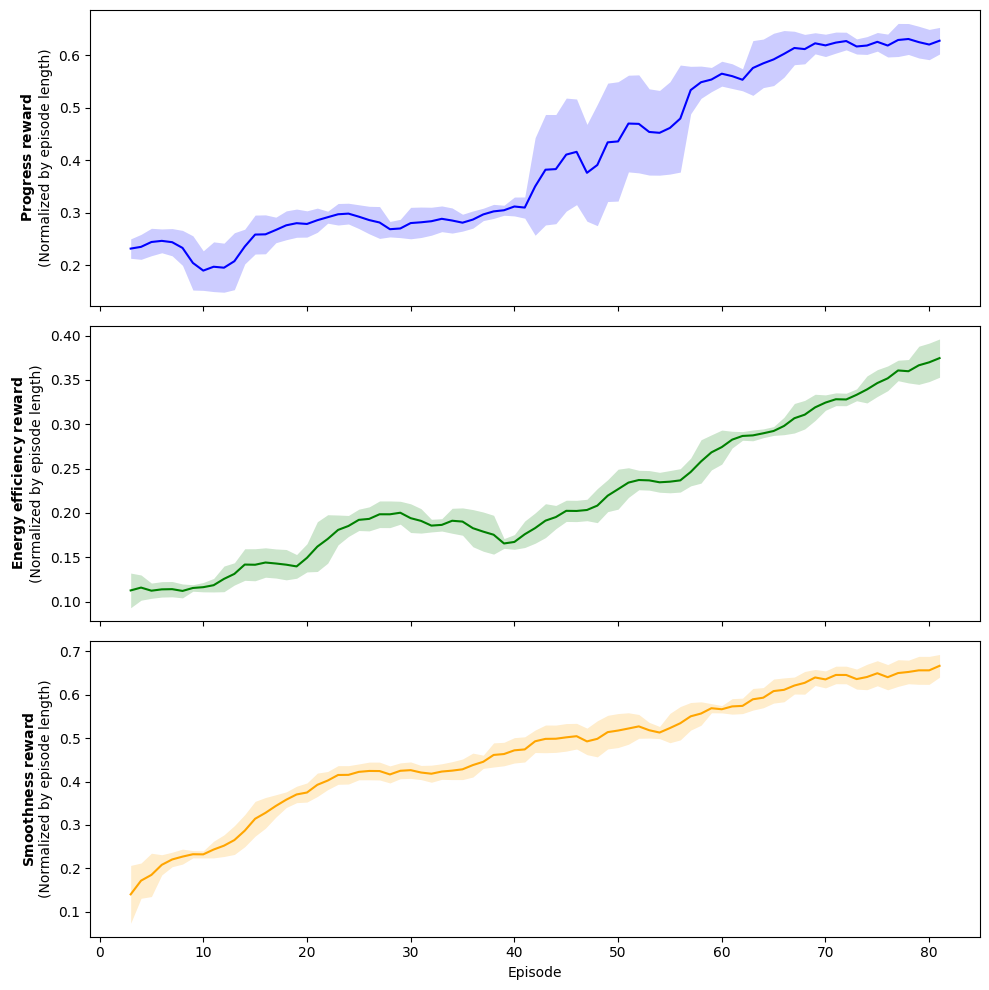

In [28]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df['episode'], df['progress_mean'], c='b')
ax[0].fill_between(df['episode'], df['progress_mean'] - df['progress_std'], df['progress_mean'] + df['progress_std'], alpha=0.2, color='b', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df['episode'], df['energy_efficiency_mean'], c='g')
ax[1].fill_between(df['episode'], df['energy_efficiency_mean'] - df['energy_efficiency_std'], df['energy_efficiency_mean'] + df['energy_efficiency_std'], alpha=0.2, color='g', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df['episode'], df['smoothness_mean'], c='orange')
ax[2].fill_between(df['episode'], df['smoothness_mean'] - df['smoothness_std'], df['smoothness_mean'] + df['smoothness_std'], alpha=0.2, color='orange', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Episode')
plt.tight_layout()
plt.show()

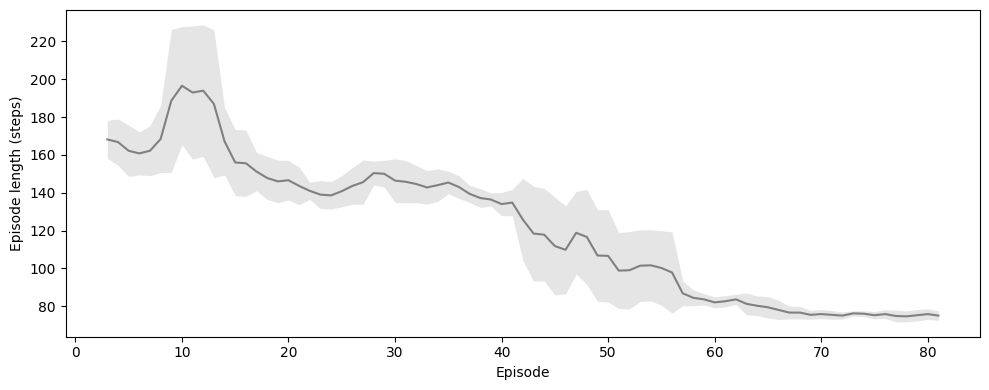

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(df['episode'], df['episode_length_mean'], c='gray')
plt.fill_between(df['episode'], df['episode_length_mean'] - df['episode_length_std'], df['episode_length_mean'] + df['episode_length_std'], alpha=0.2, color='gray', linewidth=0)
plt.ylabel('Episode length (steps)')
plt.xlabel('Episode')
plt.tight_layout()
plt.show()